<a href="https://colab.research.google.com/github/MaheshReddi15/MaheshReddy_machine-learning/blob/main/Greyscale_conversion_1andfaceblur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Hello, I am learning computer vision!")


Hello, I am learning computer vision!


Image successfully downloaded and decoded. Displaying image.


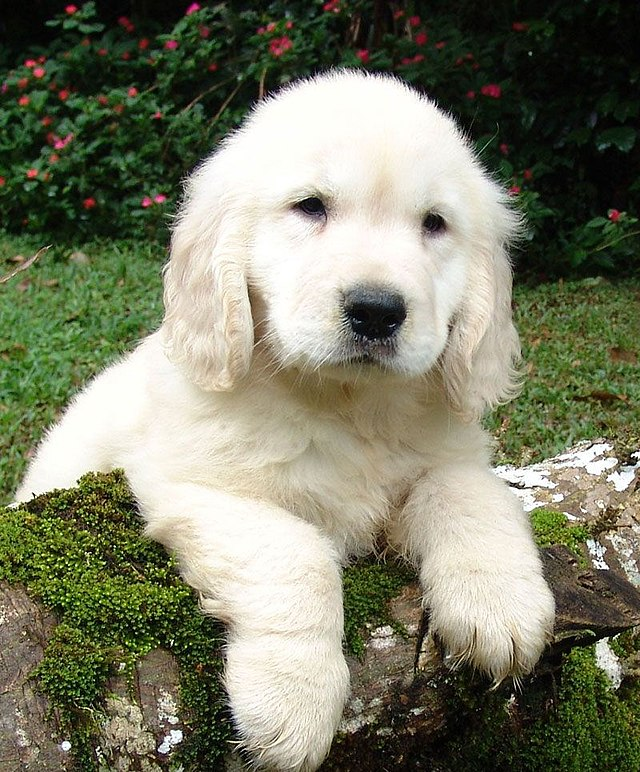

In [3]:
import cv2
from google.colab.patches import cv2_imshow
import requests
import numpy as np

# Define the image URL
image_url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/6/6e/Golde33443.jpg/640px-Golde33443.jpg'

# Download the image using requests
try:
    response = requests.get(image_url)
    response.raise_for_status() # Raise an exception for bad status codes
    # Convert the image data to a numpy array
    image_array = np.frombuffer(response.content, np.uint8)
    # Decode the image array into a cv2 image
    image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

    # Check if the image was loaded successfully
    if image is not None:
        print("Image successfully downloaded and decoded. Displaying image.")
        cv2_imshow(image)
    else:
        # If image is None, it means cv2.imdecode failed
        print("Error: Could not decode image. The downloaded data might not be a valid image or the format is unsupported.")
        print(f"Downloaded content type: {response.headers.get('Content-Type')}")


except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}")

Showing grayscale version:


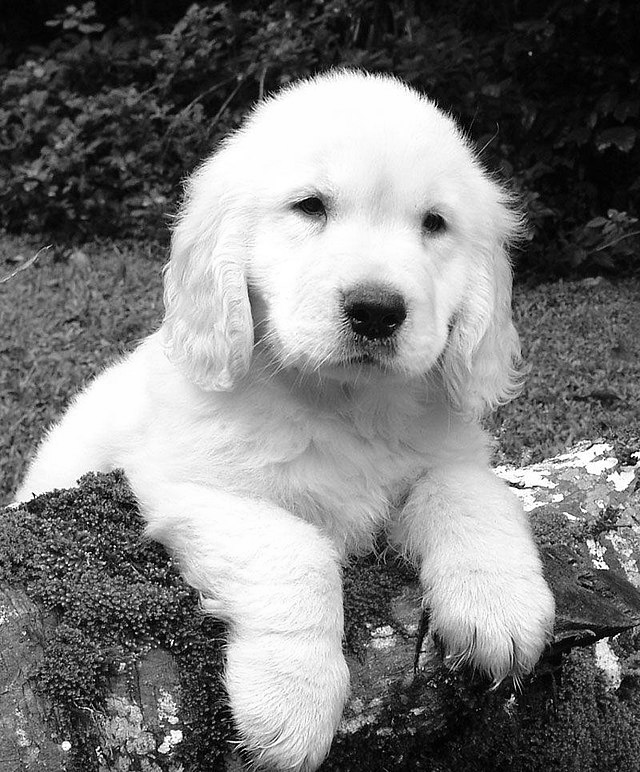

In [4]:
# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display grayscale image
print("Showing grayscale version:")
cv2_imshow(gray_image)



Found 1 face(s) in the image.


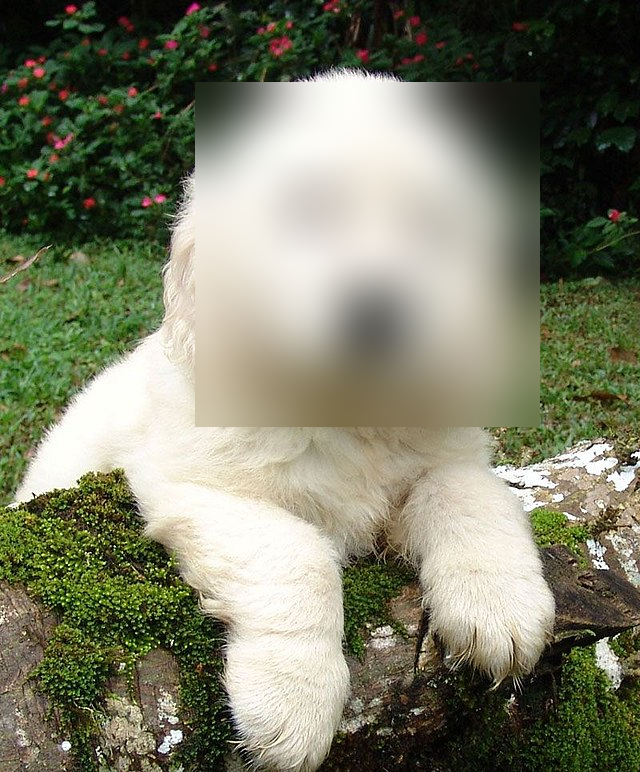

In [6]:
# Load the Haar Cascade face detector (pre-trained model)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Convert your image to grayscale (if not already)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect faces in the image
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

# Draw rectangles around faces
image_with_faces = image.copy()
for (x, y, w, h) in faces:
  # Extract the face region
  face_region = image_with_faces[y:y+h, x:x+w]
  # Apply Gaussian blur to the face region
  blurred_face = cv2.GaussianBlur(face_region, (99, 99), 30)
  # Replace the original face with the blurred face
  image_with_faces[y:y+h, x:x+w] = blurred_face


# Show the result
print(f"Found {len(faces)} face(s) in the image.")
cv2_imshow(image_with_faces)

